# Port Value Models

We have a variety of models that estimate the expected value (reward probability) of each port (A/B/C) based on the rat's experience over a session.


| Model | Free parameters | Concept |
|---|---|---|
| **Rescorla-Wagner** | α (learning rate), decay | Q ← Q + α · (reward − Q) |
| **Bayesian** | prior_strength (similar to learning rate), decay | Beta(a, b) posterior per port; update a or b on each port visit |
| **Hidden State** | α (learning rate), decay | Bayesian belief over which permutation of known reward probabilities is active |

We provide 2 sets of example port visit and reward data (comment out each one to see how the models fit each of the 2 sessions)!

In [27]:
import sys
sys.path.append('..') # Use sys to add the parent directory (where src/hexmaze lives) to the path

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from src.hexmaze.rl.port_learning import (
    RescorlaWagner, 
    BayesianPortLearner,
    HiddenStatePortLearner, 
)

# Example port visits and reward outcomes from rat IM-1478, 07/26/2022
# Probability change session with 3 reward blocks and 134 trials
# This rat visits all 3 ports fairly consistently throughout this session
rewards = np.array([0,0,1,0,1,1,1,0,0,1,0,1,0,1,0,1,1,0,1,1,0,0,1,0,0,1,0,1,1,0,1,1,0,0,1,1,1,
 0,0,1,1,1,1,0,1,0,0,1,1,0,1,0,1,1,1,0,1,0,1,1,1,1,1,0,0,1,1,1,1,1,1,0,0,1,
 0,1,0,0,0,1,0,1,0,0,0,1,1,1,0,1,1,0,0,0,1,0,1,0,1,1,1,0,0,1,0,1,1,1,0,1,0,
 1,1,1,1,0,0,0,1,0,1,1,0,0,1,0,0,1,0,0,0,0,0,1])
ports = np.array(['A','B','C','B','A','C','A','B','C','A','B','C','B','A','B','C','A','B',
 'C','A','B','C','A','B','C','A','B','C','A','B','A','B','C','B','A','C',
 'A','B','C','A','B','C','A','B','C','A','B','C','A','B','C','B','C','A',
 'C','B','A','C','A','B','C','A','B','C','A','B','C','A','B','C','B','C',
 'A','B','C','B','C','B','A','B','C','A','B','C','A','B','A','B','C','A',
 'B','A','B','C','B','A','B','C','B','C','B','C','A','B','C','B','A','B',
 'C','B','C','A','B','A','B','C','B','C','B','C','A','B','A','B','C','A',
 'B','C','B','A','B','C','A','B'])

# Example port visits and reward outcomes from rat Toby, 03/18/2025, epoch 1
# Probability change session with 3 reward blocks and 207 trials
# This rat highly favors the 90%/50% ports and rarely visits the 10% port at the end of blocks
# This behavioral pattern reflects knowledge of the structure of the environment 
# (e.g. "the other 2 ports are good and medium, so that one must be bad")
# The hidden state model is the best option for modeling port values here:
# In the Rescorla-Wagner (classic Q) and Bayesian models that treat each port independently,
# the unvisited 10% port's value decays back towards the prior of 50%, which does not 
# seem to reflect the rat's idea of the port's (low) value. In the hidden state model, the 
# rat's confident estimate of the often-visited 90% and 50% ports are able to inform a
# confident estimate that the unvisited port must have low value
# ports = np.array(['B', 'A', 'C', 'A', 'B', 'C', 'B', 'A', 'C', 'A', 'B', 'C', 'B',
#        'A', 'B', 'C', 'B', 'A', 'B', 'C', 'B', 'C', 'B', 'C', 'B', 'C',
#        'B', 'C', 'B', 'A', 'B', 'C', 'A', 'B', 'C', 'A', 'B', 'C', 'B',
#        'C', 'B', 'C', 'B', 'C', 'B', 'C', 'B', 'A', 'B', 'C', 'B', 'C',
#        'A', 'B', 'C', 'B', 'C', 'B', 'C', 'B', 'C', 'B', 'C', 'B', 'C',
#        'B', 'C', 'B', 'C', 'B', 'C', 'B', 'C', 'B', 'C', 'B', 'C', 'B',
#        'C', 'A', 'B', 'C', 'A', 'B', 'C', 'B', 'C', 'A', 'B', 'C', 'A',
#        'B', 'C', 'A', 'B', 'C', 'A', 'B', 'C', 'A', 'B', 'C', 'A', 'B',
#        'C', 'A', 'B', 'C', 'A', 'B', 'A', 'B', 'C', 'A', 'B', 'C', 'A',
#        'B', 'A', 'B', 'A', 'B', 'A', 'B', 'A', 'B', 'A', 'B', 'A', 'B',
#        'A', 'B', 'A', 'B', 'A', 'C', 'A', 'B', 'A', 'B', 'A', 'C', 'A',
#        'B', 'A', 'B', 'C', 'A', 'C', 'A', 'B', 'A', 'C', 'B', 'A', 'C',
#        'A', 'B', 'C', 'A', 'B', 'C', 'B', 'C', 'B', 'C', 'B', 'C', 'B',
#        'A', 'C', 'B', 'C', 'B', 'C', 'B', 'C', 'A', 'C', 'B', 'C', 'B',
#        'C', 'B', 'C', 'B', 'C', 'B', 'C', 'B', 'C', 'A', 'C', 'B', 'C',
#        'B', 'C', 'B', 'C', 'B', 'C', 'B', 'C', 'B', 'C', 'B', 'C'])
# rewards = np.array([1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,
#        1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
#        1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
#        0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
#        0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
#        1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
#        1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
#        0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
#        0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1,
#        1, 0, 1, 1, 1, 1, 1, 0, 1])


n = len(rewards)
trials = np.arange(0, n + 1)
port_labels = {1: 'A', 2: 'B', 3: 'C'}
colors = {1: '#e41a1c', 2: '#377eb8', 3: '#4daf4a'}

print(f'Total trials: {n}, overall reward rate: {rewards.mean():.2f}')
for p, label in port_labels.items():
    mask = ports == label
    print(f'  Port {label}: {mask.sum()} visits, reward rate = {rewards[mask].mean():.2f}')

Total trials: 134, overall reward rate: 0.54
  Port A: 40 visits, reward rate = 0.68
  Port B: 52 visits, reward rate = 0.50
  Port C: 42 visits, reward rate = 0.45


## Fit port value models to port visit and reward data

Each model's free parameters are fit by minimizing negative log-likelihood (NLL) over the port visit / reward sequence.

We can compare the fit of different models using Bayesian Information Criterion (BIC).

BIC = k·ln(n) + 2·NLL penalizes extra parameters so models with different numbers of free parameters
can be compared on the same scale (lower is better).

All of our models only have 2 free parameters (for now) so we can also just compare NLL.

In [28]:
# Fit a standard Rescorla-Wagner model (basic Q learning)
rw_fit = RescorlaWagner.fit(ports, rewards)

# Fit a Beta(a, b) posterior per port
bayes_fit = BayesianPortLearner.fit(ports, rewards)

# Fit hidden state model
hs_fit = HiddenStatePortLearner.fit(ports, rewards)

# Print model stats
print(f"{'Model':<26} {'k':>2} {'NLL':>8} {'BIC':>8}  Best-fit parameters")
print('-' * 82)
print(f"{'Rescorla-Wagner':<26} {'2':>2} {rw_fit.nll_:>8.2f} {rw_fit.bic_:>8.2f}  "
      f"alpha={rw_fit.alpha:.3f}, decay={rw_fit.decay:.3f}")
print(f"{'Bayesian':<26} {'2':>2} {bayes_fit.nll_:>8.2f} {bayes_fit.bic_:>8.2f}  "
      f"prior_strength={bayes_fit.prior_a:.3f}, decay={bayes_fit.decay:.3f}")
print(f"{'Hidden State':<26} {'2':>2} {hs_fit.nll_:>8.2f} {hs_fit.bic_:>8.2f}  "
      f"alpha={hs_fit.alpha:.3f}, decay={hs_fit.decay:.4f}")

# Model that best explains the series of rewards/omissions is the one with the lowest BIC
bics = {'Rescorla-Wagner': rw_fit.bic_, 'Bayesian': bayes_fit.bic_, 'Hidden State': hs_fit.bic_}
print(f"\nBest model (lowest BIC): {min(bics, key=bics.get)}")

Model                       k      NLL      BIC  Best-fit parameters
----------------------------------------------------------------------------------
Rescorla-Wagner             2    80.95   171.69  alpha=0.252, decay=0.058
Bayesian                    2    80.72   171.24  prior_strength=0.695, decay=0.134
Hidden State                2    77.74   165.27  alpha=0.823, decay=0.0375

Best model (lowest BIC): Hidden State


## Best-Fit Port Value Evolution

Each panel shows how a model's estimated reward probability for each port evolves trial by trial
when run with its best-fit parameters. Vertical markers at the bottom show individual port visits
(tall = reward, short = no reward).  

The graphs look similar for all of the models because they are all fit to the same data.

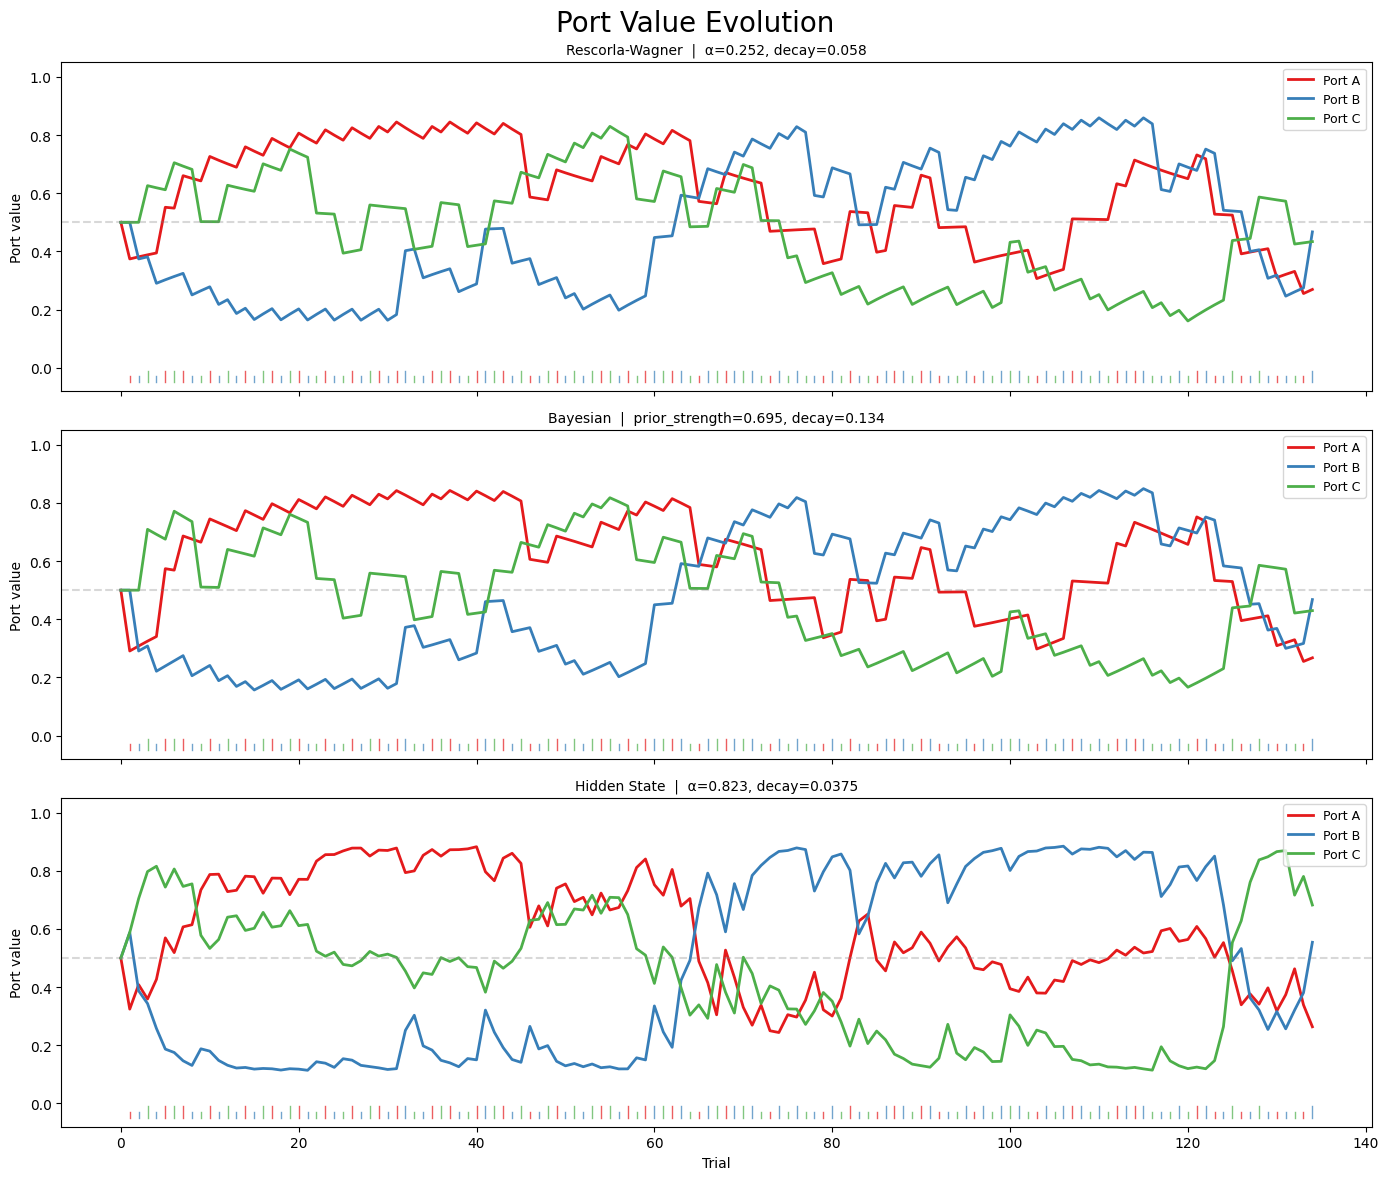

In [29]:
## Rescorla-Wagner (classic Q learning)

# Set up RescorlaWagner model with best-fit alpha and decay (from rw_fit model above)
rw = RescorlaWagner(alpha=rw_fit.alpha, decay=rw_fit.decay)
# Get initial port Q values (before the first trial)
rw_traces = {port: [rw.initial_value] for port in [1, 2, 3]}
# Learn port Q values over time based on port visits and rewards
rw.learn(ports, rewards)
# Get evolution of port Q values from model.get_history
for step in rw.get_history():
    for p in [1, 2, 3]:
        rw_traces[p].append(step['Q'][p])

## Bayesian

# Set up BayesianPortLearner with best-fit prior_a / prior_b and decay (from bayes_fit model above)
bayes = BayesianPortLearner(prior_a=bayes_fit.prior_a, prior_b=bayes_fit.prior_b,
                            decay=bayes_fit.decay)
# Get initial port Q values (before the first trial)
bayes_initial = bayes_fit.prior_a / (bayes_fit.prior_a + bayes_fit.prior_b)
bayes_traces = {p: [bayes_initial] for p in [1, 2, 3]}
# Learn port Q values over time based on port visits and rewards
bayes.learn(ports, rewards)
# Get evolution of port Q values from model.get_history
for step in bayes.get_history():
    for p in [1, 2, 3]:
        post = step['posteriors'][p]
        a, b = post['a'], post['b']
        bayes_traces[p].append(a / (a + b))

## Hidden State

# Set up HiddenStatePortLearner with best-fit alpha and decay (from hs_fit model above)
hs = HiddenStatePortLearner(reward_set=hs_fit.reward_set, alpha=hs_fit.alpha,
                            decay=hs_fit.decay)
# Get initial port Q values (before the first trial)
hs_initial = {p: hs.expected_value(p) for p in [1, 2, 3]}
hs_traces = {p: [hs_initial[p]] for p in [1, 2, 3]}
# Learn port Q values over time based on port visits and rewards
hs.learn(ports, rewards)
# Get evolution of port Q values from model.get_history
for step in hs.get_history():
    for p in [1, 2, 3]:
        hs_traces[p].append(step['expected_values'][p])


## Plot 

# Plot port Q values from each model
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
panel_data = [
    ('Rescorla-Wagner', f"α={rw_fit.alpha:.3f}, decay={rw_fit.decay:.3f}", rw_traces),
    ('Bayesian', f"prior_strength={bayes_fit.prior_a:.3f}, decay={bayes_fit.decay:.3f}", bayes_traces),
    ('Hidden State', f"α={hs_fit.alpha:.3f}, decay={hs_fit.decay:.4f}", hs_traces),
]

for ax, (name, subtitle, traces) in zip(axes, panel_data):
    for p in [1, 2, 3]:
        ax.plot(trials, traces[p], label=f'Port {port_labels[p]}', color=colors[p], linewidth=2)

    # Reward markers: tall line = reward, short line = omission
    for i, (port, rew) in enumerate(zip(ports, rewards)):
        pnum = {'A': 1, 'B': 2, 'C': 3}[port]
        top = -0.01 if rew else -0.03
        ax.plot([i + 1, i + 1], [-0.05, top], color=colors[pnum], linewidth=1, alpha=0.7)

    ax.set_title(f'{name}  |  {subtitle}', fontsize=10)
    ax.set_ylabel('Port value')
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim(-0.08, 1.05)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)

axes[-1].set_xlabel('Trial')
fig.suptitle('Port Value Evolution', fontsize=20)
plt.tight_layout()
plt.show()

## Uncertainty / Confidence Intervals

The Bayesian model has a natural posterior uncertainty (Beta credible intervals) and the Hidden State model
has belief-spread uncertainty (±1 SD across permutation-weighted port probabilities). Each figure below
shows all three ports together, then each port individually so the bands are easier to see.

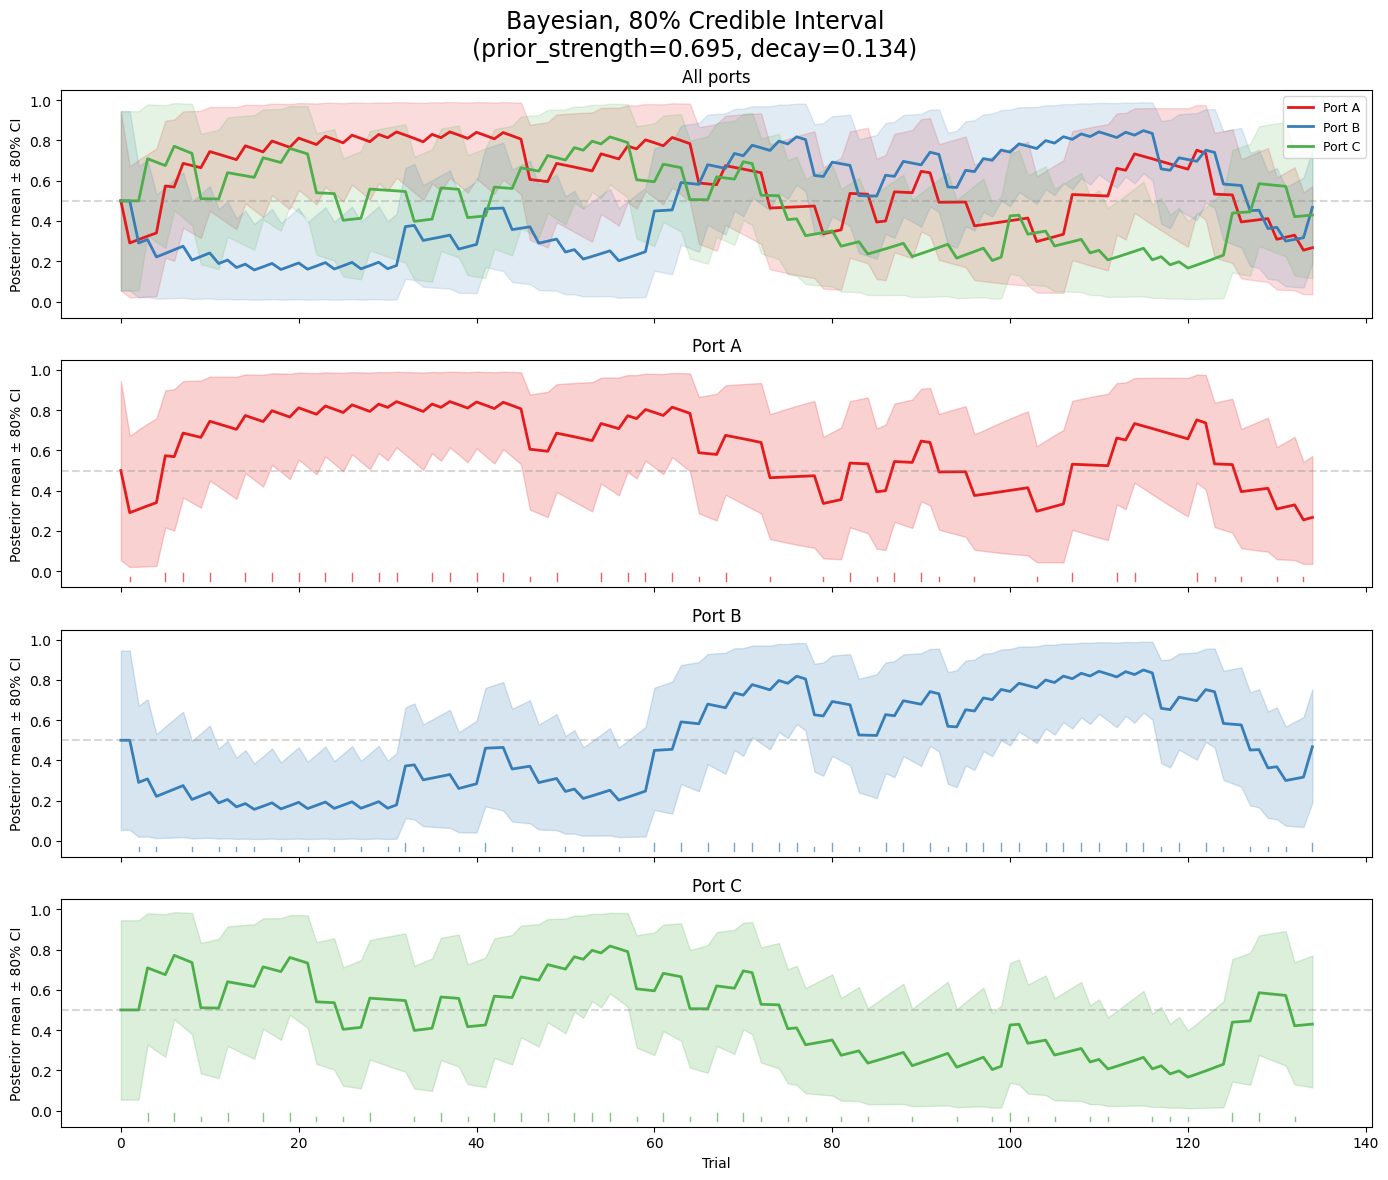

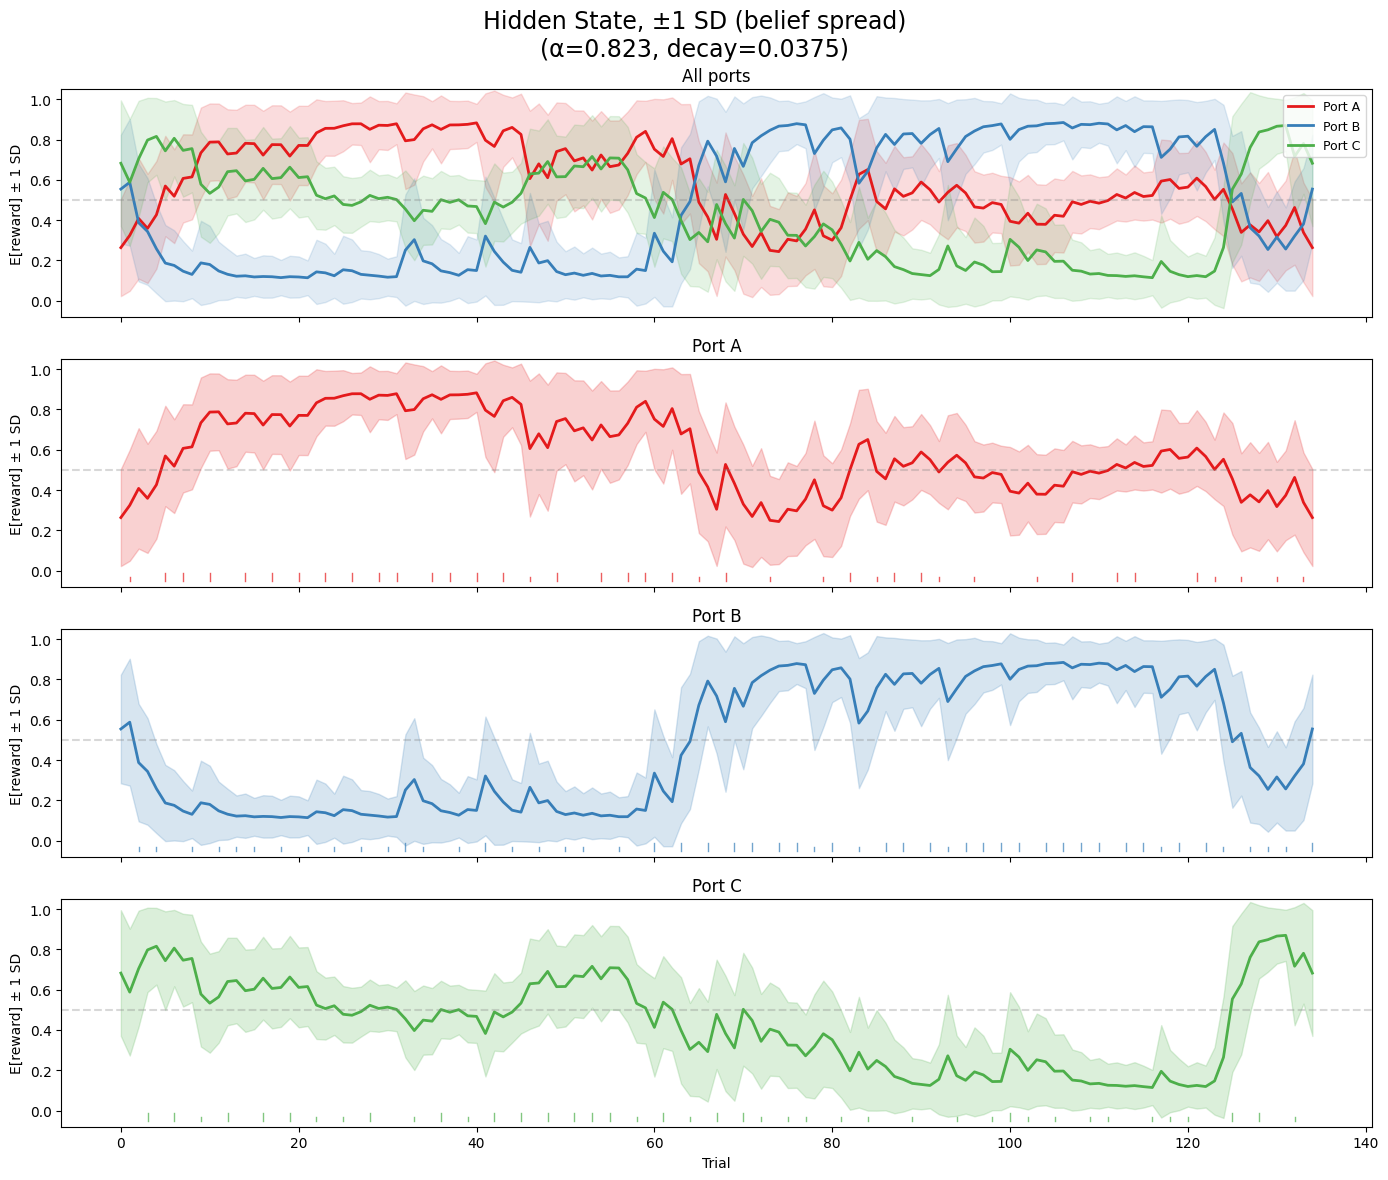

In [30]:
## Bayesian

# Set up BayesianPortLearner with best-fit params
bayes_ci = BayesianPortLearner(prior_a=bayes_fit.prior_a, prior_b=bayes_fit.prior_b, decay=bayes_fit.decay)
# Learn port Q values over time based on port visits and rewards
bayes_ci.learn(ports, rewards)
bayes_mean = {p: [bayes_initial] for p in [1, 2, 3]}
bayes_lo = {p: [stats.beta(bayes_fit.prior_a, bayes_fit.prior_b).ppf(0.1)] for p in [1, 2, 3]}
bayes_hi = {p: [stats.beta(bayes_fit.prior_a, bayes_fit.prior_b).ppf(0.9)] for p in [1, 2, 3]}
for step in bayes_ci.get_history():
    for p in [1, 2, 3]:
        post = step['posteriors'][p]
        a, b = post['a'], post['b']
        bayes_mean[p].append(a / (a + b))
        dist = stats.beta(a, b)
        bayes_lo[p].append(dist.ppf(0.1))
        bayes_hi[p].append(dist.ppf(0.9))

## Hidden State

# Set up HiddenStatePortLearner with best-fit params
hs_ci = HiddenStatePortLearner(reward_set=hs_fit.reward_set, alpha=hs_fit.alpha, decay=hs_fit.decay)
# Learn port Q values over time based on port visits and rewards
hs_ci.learn(ports, rewards)
hs_ci_initial = {p: hs_ci.expected_value(p) for p in [1, 2, 3]}
hs_ci_initial_std = {p: hs_ci.expected_value_std(p) for p in [1, 2, 3]}
hs_mean = {p: [hs_ci_initial[p]] for p in [1, 2, 3]}
hs_lo = {p: [hs_ci_initial[p] - hs_ci_initial_std[p]] for p in [1, 2, 3]}
hs_hi = {p: [hs_ci_initial[p] + hs_ci_initial_std[p]] for p in [1, 2, 3]}
for step in hs_ci.get_history():
    for p in [1, 2, 3]:
        ev = step['expected_values'][p]
        sd = step['expected_value_stds'][p]
        hs_mean[p].append(ev)
        hs_lo[p].append(ev - sd)
        hs_hi[p].append(ev + sd)

## Helper to plot one model's CI figure (4 vertical subplots)
def plot_ci_figure(title, mean_traces, lo, hi, ci_label):
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

    # Top panel: all ports together
    for p in [1, 2, 3]:
        axes[0].plot(trials, mean_traces[p], label=f'Port {port_labels[p]}',
                     color=colors[p], linewidth=2)
        axes[0].fill_between(trials, lo[p], hi[p], color=colors[p], alpha=0.15)
    axes[0].set_title('All ports')
    axes[0].legend(loc='upper right', fontsize=9)

    # Bottom 3 panels: one port each (so we can see shaded region better)
    for idx, p in enumerate([1, 2, 3]):
        ax = axes[idx + 1]
        ax.plot(trials, mean_traces[p], label=f'Port {port_labels[p]}',
                color=colors[p], linewidth=2)
        ax.fill_between(trials, lo[p], hi[p], color=colors[p], alpha=0.2)
        ax.set_title(f'Port {port_labels[p]}')

        # Reward markers for this port only
        for i, (pt, rew) in enumerate(zip(ports, rewards)):
            if pt == port_labels[p]:
                top = -0.01 if rew else -0.03
                ax.plot([i + 1, i + 1], [-0.05, top], color=colors[p],
                        linewidth=1, alpha=0.7)

    for ax in axes:
        ax.set_ylabel(ci_label)
        ax.set_ylim(-0.08, 1.05)
        ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)

    axes[-1].set_xlabel('Trial')
    fig.suptitle(title, fontsize=17)
    plt.tight_layout()
    plt.show()

# Bayesian: 80% credible interval
plot_ci_figure(
    f'Bayesian, 80% Credible Interval\n'
    f'(prior_strength={bayes_fit.prior_a:.3f}, decay={bayes_fit.decay:.3f})',
    bayes_mean, bayes_lo, bayes_hi,
    'Posterior mean ± 80% CI'
)

# Hidden State: ±1 SD from belief spread
plot_ci_figure(
    f'Hidden State, ±1 SD (belief spread)\n'
    f'(α={hs_fit.alpha:.3f}, decay={hs_fit.decay:.4f})',
    hs_mean, hs_lo, hs_hi,
    'E[reward] ± 1 SD'
)

## Rescorla-Wagner

**learning rate (alpha)** controls how much a port's Q value is updated based on a new observation

**decay** controls how much a port's Q value decays back towards the prior (0.5), modelling forgetting / uncertainty

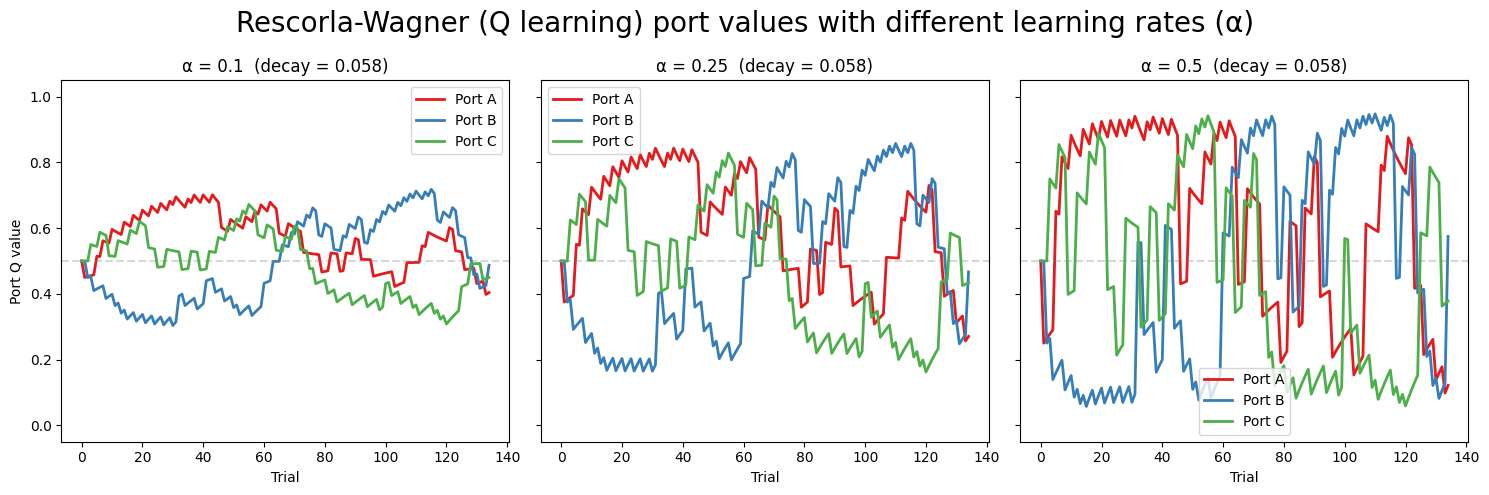

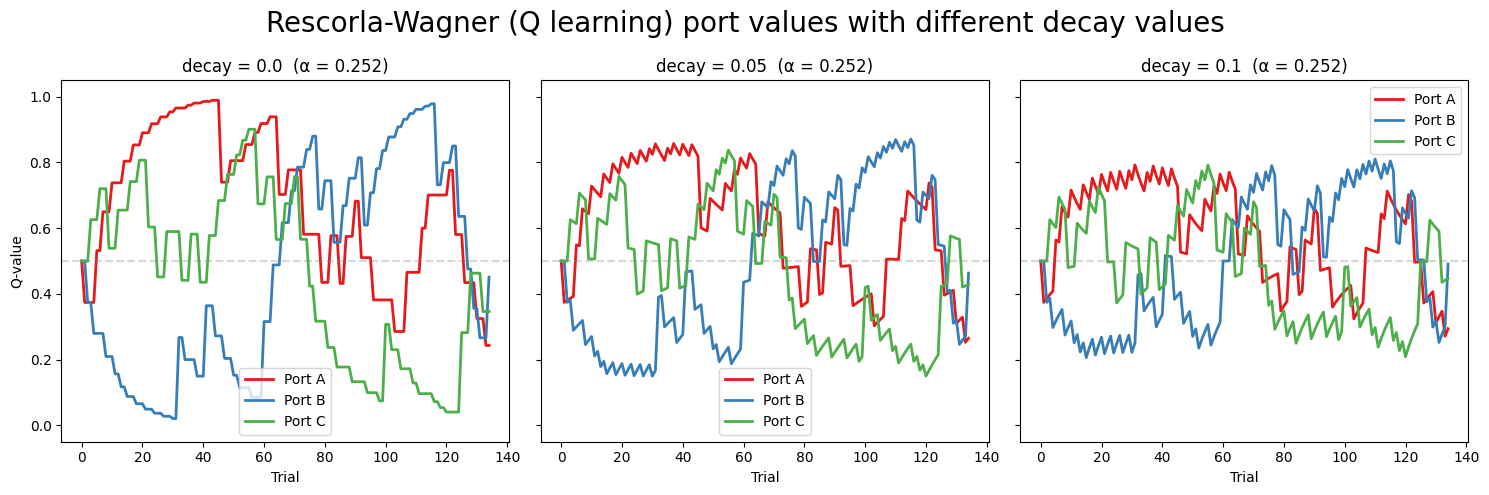

In [31]:
## Look at the effect of learning rate (alpha)

# Keep decay fixed at best-fit value, use 3 different learning rates (alphas) for comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, alpha in zip(axes, [0.1, 0.25, 0.5]):
    # Set up model with given alpha and decay
    model = RescorlaWagner(alpha=alpha, decay=rw_fit.decay)
    # Learn port Q values based on port visits and rewards
    model.learn(ports, rewards)
    # Get initial port Q values (before the first trial)
    port_q_value_traces = {port: [model.initial_value] for port in [1, 2, 3]}
    # Get evolution of port Q values from model.get_history
    for step in model.get_history():
        for port in [1, 2, 3]:
               port_q_value_traces[port].append(step['Q'][port])
    # Plot Q values for each port
    for port in [1, 2, 3]:
        ax.plot(trials, port_q_value_traces[port], label=f'Port {port_labels[port]}', color=colors[port], linewidth=2)
    ax.set_title(f'α = {alpha}  (decay = {rw_fit.decay:.3f})')
    ax.set_xlabel('Trial')
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)

axes[0].set_ylabel('Port Q value')
fig.suptitle('Rescorla-Wagner (Q learning) port values with different learning rates (α)', fontsize=20)
plt.tight_layout()
plt.show()

## Look at the effect of decay

# Keep learning rate (alpha) fixed at best-fit value, use 3 different decay values for comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, decay in zip(axes, [0.0, 0.05, 0.1]):
    # Set up model with given alpha and decay
    model = RescorlaWagner(alpha=rw_fit.alpha, decay=decay)
    # Learn port Q values based on port visits and rewards
    model.learn(ports, rewards)
    # Get initial port Q values (before the first trial)
    port_q_value_traces = {port: [model.initial_value] for port in [1, 2, 3]}
    # Get evolution of port Q values from model.get_history
    for step in model.get_history():
        for port in [1, 2, 3]:
            port_q_value_traces[port].append(step['Q'][port])
    # Plot Q values for each port
    for port in [1, 2, 3]:
        ax.plot(trials, port_q_value_traces[port], label=f'Port {port_labels[port]}', color=colors[port], linewidth=2)
    ax.set_title(f'decay = {decay}  (α = {rw_fit.alpha:.3f})')
    ax.set_xlabel('Trial')
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)

axes[0].set_ylabel('Q-value')
fig.suptitle('Rescorla-Wagner (Q learning) port values with different decay values', fontsize=20)
plt.tight_layout()
plt.show()

## Bayesian

**prior_strength** sets the effective sample size of the Beta prior (prior_a = prior_b = prior_strength). Higher values anchor estimates toward 0.5 and require more port visits to shift — similar to a lower learning rate. We enforce prior_a = prior_b so all ports start at an expected value of 0.5

**decay** geometrically shrinks the posterior back toward the prior each trial. Higher decay makes the model forget faster and keep credible intervals wider.

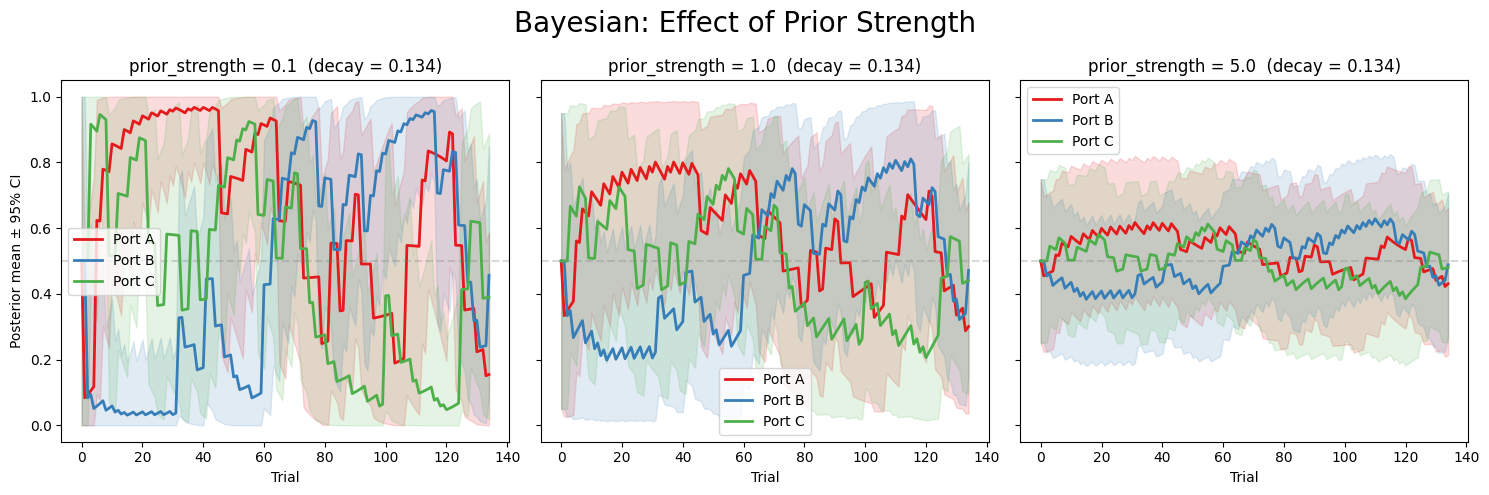

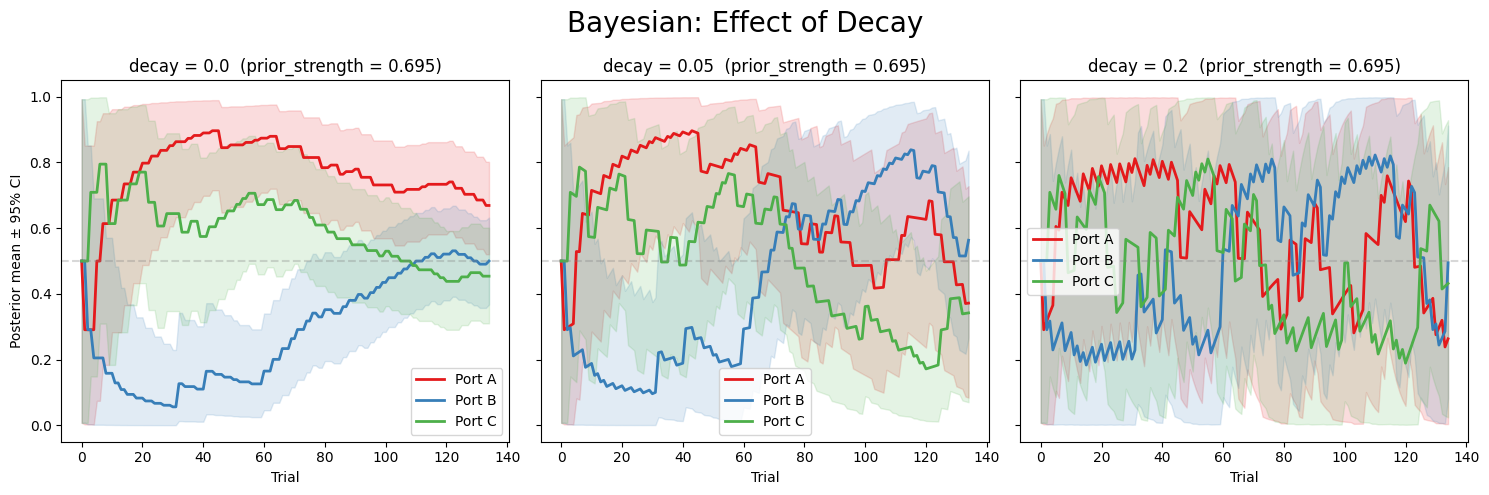

In [32]:
## Look at the effect of prior strength

# Keep decay fixed at best-fit value, use 3 different prior strengths for comparison
# Shaded bands show the 95% credible interval from the Beta posterior
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, ps in zip(axes, [0.1, 1.0, 5.0]):
    # Set up model with given prior_strength and best-fit decay
    m = BayesianPortLearner(prior_a=ps, prior_b=ps, decay=bayes_fit.decay)
    # Learn port posteriors over time based on port visits and rewards
    m.learn(ports, rewards)
    # Get initial port values (before the first trial) and CI bounds
    traces = {p: [0.5] for p in [1, 2, 3]}
    lo = {p: [stats.beta(ps, ps).ppf(0.05)] for p in [1, 2, 3]}
    hi = {p: [stats.beta(ps, ps).ppf(0.95)] for p in [1, 2, 3]}
    # Get evolution of port posteriors from model.get_history
    for step in m.get_history():
        for p in [1, 2, 3]:
            post = step['posteriors'][p]
            a, b = post['a'], post['b']
            traces[p].append(a / (a + b))
            dist = stats.beta(a, b)
            lo[p].append(dist.ppf(0.05))
            hi[p].append(dist.ppf(0.95))
    # Plot posterior mean and 95% CI for each port
    for p in [1, 2, 3]:
        ax.plot(trials, traces[p], label=f'Port {port_labels[p]}', color=colors[p], linewidth=2)
        ax.fill_between(trials, lo[p], hi[p], color=colors[p], alpha=0.15)
    ax.set_title(f'prior_strength = {ps}  (decay = {bayes_fit.decay:.3f})')
    ax.set_xlabel('Trial')
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)

axes[0].set_ylabel('Posterior mean ± 95% CI')
fig.suptitle('Bayesian: Effect of Prior Strength', fontsize=20)
plt.tight_layout()
plt.show()

## Look at the effect of decay

# Keep prior_strength fixed at best-fit value, use 3 different decay values for comparison
# Shaded bands show the 95% credible interval from the Beta posterior
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, decay in zip(axes, [0.0, 0.05, 0.2]):
    # Set up model with best-fit prior_strength and given decay
    m = BayesianPortLearner(prior_a=bayes_fit.prior_a, prior_b=bayes_fit.prior_b, decay=decay)
    # Learn port posteriors over time based on port visits and rewards
    m.learn(ports, rewards)
    # Get initial port values (before the first trial) and CI bounds
    traces = {p: [0.5] for p in [1, 2, 3]}
    lo = {p: [stats.beta(bayes_fit.prior_a, bayes_fit.prior_b).ppf(0.025)] for p in [1, 2, 3]}
    hi = {p: [stats.beta(bayes_fit.prior_a, bayes_fit.prior_b).ppf(0.975)] for p in [1, 2, 3]}
    # Get evolution of port posteriors from model.get_history
    for step in m.get_history():
        for p in [1, 2, 3]:
            post = step['posteriors'][p]
            a, b = post['a'], post['b']
            traces[p].append(a / (a + b))
            dist = stats.beta(a, b)
            lo[p].append(dist.ppf(0.025))
            hi[p].append(dist.ppf(0.975))
    # Plot posterior mean and 95% CI for each port
    for p in [1, 2, 3]:
        ax.plot(trials, traces[p], label=f'Port {port_labels[p]}', color=colors[p], linewidth=2)
        ax.fill_between(trials, lo[p], hi[p], color=colors[p], alpha=0.15)
    ax.set_title(f'decay = {decay}  (prior_strength = {bayes_fit.prior_a:.3f})')
    ax.set_xlabel('Trial')
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)

axes[0].set_ylabel('Posterior mean ± 95% CI')
fig.suptitle('Bayesian: Effect of Decay', fontsize=20)
plt.tight_layout()
plt.show()

## Hidden State

**decay** causes the structural belief (which permutation of reward probabilities is active) to reset toward uniform each trial. Higher values make the model expect more frequent reward reassignments and keep beliefs less confident.

**alpha (learning rate)** controls how much the belief is updated on each trial. alpha=1.0 is a full Bayesian update; lower values make the model more conservative / slower to shift its belief.

**reward_set** is the assumed set of reward probabilities assigned across ports. A tighter spread (e.g., 0.65/0.5/0.35) makes port assignments harder to distinguish from each other.

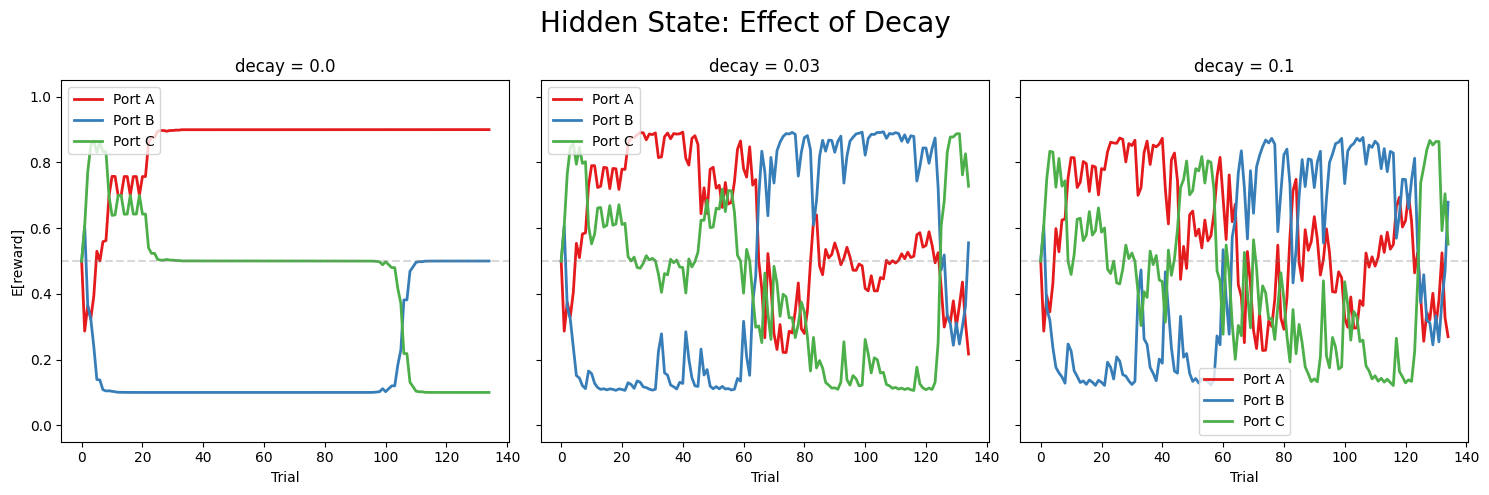

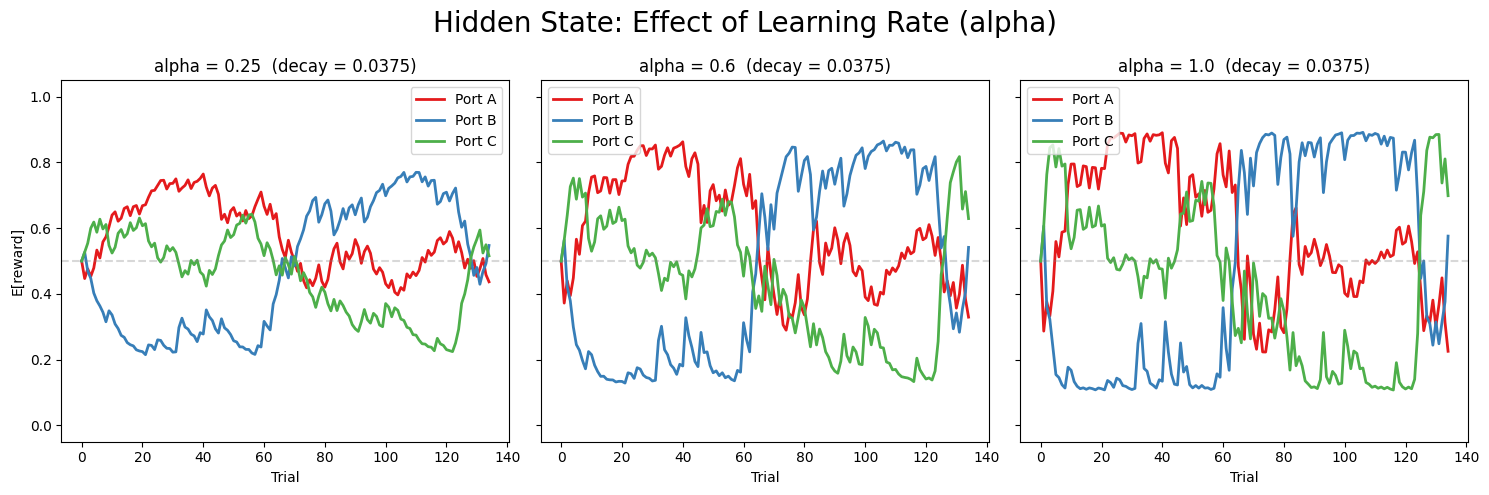

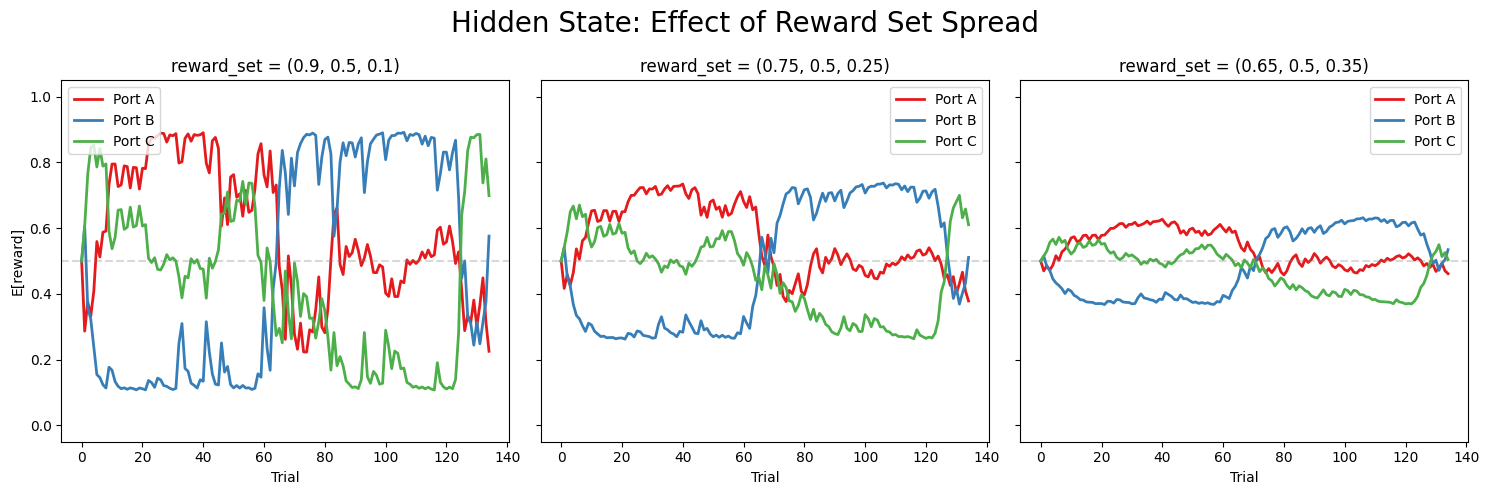

In [33]:
## Look at the effect of decay

# Keep alpha at default (1.0 = full Bayesian), use 3 different decay values for comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, d in zip(axes, [0.0, 0.03, 0.1]):
    # Set up model with given decay
    m = HiddenStatePortLearner(reward_set=hs_fit.reward_set, decay=d)
    # Get initial expected values (before the first trial)
    initial = {p: m.expected_value(p) for p in [1, 2, 3]}
    # Learn expected values over time based on port visits and rewards
    m.learn(ports, rewards)
    # Get evolution of expected values from model.get_history
    traces = {p: [initial[p]] for p in [1, 2, 3]}
    for step in m.get_history():
        for p in [1, 2, 3]:
            traces[p].append(step['expected_values'][p])
    # Plot expected values for each port
    for p in [1, 2, 3]:
        ax.plot(trials, traces[p], label=f'Port {port_labels[p]}', color=colors[p], linewidth=2)
    ax.set_title(f'decay = {d}')
    ax.set_xlabel('Trial')
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)

axes[0].set_ylabel('E[reward]')
fig.suptitle('Hidden State: Effect of Decay', fontsize=20)
plt.tight_layout()
plt.show()

## Look at the effect of learning rate (alpha)

# Keep decay fixed at best-fit value, use 3 different learning rates for comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, alpha in zip(axes, [0.25, 0.6, 1.0]):
    # Set up model with given alpha and best-fit decay
    m = HiddenStatePortLearner(reward_set=hs_fit.reward_set, alpha=alpha,
                               decay=hs_fit.decay)
    # Get initial expected values (before the first trial)
    initial = {p: m.expected_value(p) for p in [1, 2, 3]}
    # Learn expected values over time based on port visits and rewards
    m.learn(ports, rewards)
    # Get evolution of expected values from model.get_history
    traces = {p: [initial[p]] for p in [1, 2, 3]}
    for step in m.get_history():
        for p in [1, 2, 3]:
            traces[p].append(step['expected_values'][p])
    # Plot expected values for each port
    for p in [1, 2, 3]:
        ax.plot(trials, traces[p], label=f'Port {port_labels[p]}', color=colors[p], linewidth=2)
    ax.set_title(f'alpha = {alpha}  (decay = {hs_fit.decay:.4f})')
    ax.set_xlabel('Trial')
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)

axes[0].set_ylabel('E[reward]')
fig.suptitle('Hidden State: Effect of Learning Rate (alpha)', fontsize=20)
plt.tight_layout()
plt.show()

## Look at the effect of reward set spread

# Keep decay at best-fit value, use 3 different reward sets for comparison
# Tighter spreads make it harder to distinguish which port has which probability
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
reward_sets = [(0.9, 0.5, 0.1), (0.75, 0.5, 0.25), (0.65, 0.5, 0.35)]
for ax, rs in zip(axes, reward_sets):
    # Set up model with given reward set and best-fit decay
    m = HiddenStatePortLearner(reward_set=rs, decay=hs_fit.decay)
    # Get initial expected values (before the first trial)
    initial = {p: m.expected_value(p) for p in [1, 2, 3]}
    # Learn expected values over time based on port visits and rewards
    m.learn(ports, rewards)
    # Get evolution of expected values from model.get_history
    traces = {p: [initial[p]] for p in [1, 2, 3]}
    for step in m.get_history():
        for p in [1, 2, 3]:
            traces[p].append(step['expected_values'][p])
    # Plot expected values for each port
    for p in [1, 2, 3]:
        ax.plot(trials, traces[p], label=f'Port {port_labels[p]}', color=colors[p], linewidth=2)
    ax.set_title(f'reward_set = {rs}')
    ax.set_xlabel('Trial')
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)

axes[0].set_ylabel('E[reward]')
fig.suptitle('Hidden State: Effect of Reward Set Spread', fontsize=20)
plt.tight_layout()
plt.show()

## Other Useful Methods

Beyond `.fit()` and `.learn()`, each learner has methods for inspecting state, 
getting uncertainty estimates, and simulating choice behavior. These work the same way
across all three models (with some model-specific extras).

In [37]:
## update() — single-step learning
# Instead of calling .learn() on a full sequence, you can step through trials one at a time.
# update() returns the reward prediction error (RW) or surprise (Bayesian / Hidden State).

rw = RescorlaWagner(alpha=0.3, decay=0.05)

# Step through the first 5 trials one at a time
for i in range(5):
    rpe = rw.update(ports[i], rewards[i])
    print(f"Trial {i+1}: port={ports[i]}, reward={rewards[i]}, "
          f"prediction_error={rpe:+.3f}, Q={rw.get_values()}")

## get_values() — snapshot of current port values
# Works on all three models. Returns a dict {port: value}.
print("\n--- get_values() ---")

# RW: returns current Q values
print(f"RW Q-values:       {rw.get_values()}")

# Bayesian: returns posterior means
bayes = BayesianPortLearner(prior_a=1.0, prior_b=1.0, decay=0.05)
bayes.learn(ports[:20], rewards[:20])
print(f"Bayesian means:    {bayes.get_values()}")

# Hidden State: returns belief-weighted expected values
hs = HiddenStatePortLearner(reward_set=(0.9, 0.5, 0.1), decay=0.03)
hs.learn(ports[:20], rewards[:20])
print(f"Hidden State EVs:  {hs.get_values()}")

## choice_probabilities() — softmax action selection
# Returns a dict {port: probability} for choosing each port, based on current values.
# Useful for simulating choice behavior or computing action likelihoods.
print("\n--- choice_probabilities() ---")

# Default softmax temperature=1.0: probabilities reflect value differences

# Higher softmax temperature is more exploratory (closer to uniform)
print(f"RW choice probs (temp=1.0):      {rw.choice_probabilities()}")

# Lower softmax temperature is more exploitative (closer to argmax)
rw_greedy = RescorlaWagner(alpha=0.3, temperature=0.1, decay=0.05)
rw_greedy.learn(ports[:20], rewards[:20])
print(f"RW choice probs (temp=0.1):      {rw_greedy.choice_probabilities()}")

# You can also restrict to a subset of available ports
print(f"RW choice probs (A vs C only):   {rw_greedy.choice_probabilities(available_ports=[1, 3])}")

## reset() — reuse a model with different data
# Clears all learned values and history, keeping the same parameters.
print("\n--- reset() ---")
print(f"Before reset: {rw.get_values()}")
rw.reset()
print(f"After reset:  {rw.get_values()}")

Trial 1: port=A, reward=0, prediction_error=-0.500, Q={1: np.float64(0.35), 2: 0.5, 3: 0.5}
Trial 2: port=B, reward=0, prediction_error=-0.500, Q={1: np.float64(0.3575), 2: np.float64(0.35), 3: 0.5}
Trial 3: port=C, reward=1, prediction_error=+0.500, Q={1: np.float64(0.364625), 2: np.float64(0.3575), 3: np.float64(0.65)}
Trial 4: port=B, reward=0, prediction_error=-0.365, Q={1: np.float64(0.37139374999999997), 2: np.float64(0.2552375), 3: np.float64(0.6425)}
Trial 5: port=A, reward=1, prediction_error=+0.622, Q={1: np.float64(0.56447684375), 2: np.float64(0.267475625), 3: np.float64(0.6353749999999999)}

--- get_values() ---
RW Q-values:       {1: np.float64(0.56447684375), 2: np.float64(0.267475625), 3: np.float64(0.6353749999999999)}
Bayesian means:    {1: 0.7895624961868131, 2: 0.15667673066575297, 3: 0.73421529493428}
Hidden State EVs:  {1: np.float64(0.7797428695997028), 2: np.float64(0.10900862266594122), 3: np.float64(0.611248507734356)}

--- choice_probabilities() ---
RW choice

## Model-Specific Methods

Each model also has methods that are unique to its internal representation.

In [38]:
## Bayesian-specific: get_posteriors() and confidence_interval()

# get_posteriors() returns the raw Beta(a, b) parameters for each port
bayes = BayesianPortLearner(prior_a=1.0, prior_b=1.0, decay=0.05)
bayes.learn(ports, rewards)

print("--- get_posteriors() ---")
for port, post in bayes.get_posteriors().items():
    print(f"  Port {port_labels[port]}: Beta(a={post['a']:.2f}, b={post['b']:.2f})  →  "
          f"mean={post['a']/(post['a']+post['b']):.3f}")

# confidence_interval() returns a credible interval for a port's reward probability
# Default is 95% CI; you can pass any width
print("\n--- confidence_interval() ---")
for port in [1, 2, 3]:
    lo95, hi95 = bayes.confidence_interval(port, ci=0.95)
    lo80, hi80 = bayes.confidence_interval(port, ci=0.80)
    print(f"  Port {port_labels[port]}: 95% CI = [{lo95:.3f}, {hi95:.3f}]  "
          f"80% CI = [{lo80:.3f}, {hi80:.3f}]")

## Hidden State-specific: get_state_posteriors() and get_stds()

# get_state_posteriors() shows the model's belief over all possible port-to-probability assignments
# Each "state" is one permutation of the reward set (e.g., A=0.9, B=0.5, C=0.1)
hs = HiddenStatePortLearner(reward_set=(0.9, 0.5, 0.1), decay=0.03)
hs.learn(ports, rewards)

print("\n--- get_state_posteriors() ---")
print("Belief over all 6 permutations of (0.9, 0.5, 0.1) across ports A/B/C:")
for state in hs.get_state_posteriors():
    assignment = state['assignment']
    prob = state['probability']
    label = ", ".join(f"{port_labels[p]}={assignment[p]}" for p in [1, 2, 3])
    bar = "█" * int(prob * 50)
    print(f"  [{label}]  P={prob:.4f}  {bar}")

# get_stds() returns the standard deviation of expected reward for each port
# High SD = model is uncertain about which probability this port has
# Low SD = model is confident about this port's assignment
print("\n--- get_stds() ---")
print("Uncertainty (SD) per port:")
for port, sd in hs.get_stds().items():
    ev = hs.expected_value(port)
    print(f"  Port {port_labels[port]}: E[reward]={ev:.3f} ± {sd:.3f}")

--- get_posteriors() ---
  Port A: Beta(a=2.90, b=4.68)  →  mean=0.382
  Port B: Beta(a=5.98, b=4.71)  →  mean=0.560
  Port C: Beta(a=2.73, b=4.97)  →  mean=0.355

--- confidence_interval() ---
  Port A: 95% CI = [0.098, 0.724]  80% CI = [0.170, 0.610]
  Port B: 95% CI = [0.271, 0.827]  80% CI = [0.366, 0.748]
  Port C: 95% CI = [0.084, 0.696]  80% CI = [0.150, 0.578]

--- get_state_posteriors() ---
Belief over all 6 permutations of (0.9, 0.5, 0.1) across ports A/B/C:
  [A=0.9, B=0.5, C=0.1]  P=0.0241  █
  [A=0.9, B=0.1, C=0.5]  P=0.0053  
  [A=0.5, B=0.9, C=0.1]  P=0.1190  █████
  [A=0.5, B=0.1, C=0.9]  P=0.1144  █████
  [A=0.1, B=0.9, C=0.5]  P=0.1395  ██████
  [A=0.1, B=0.5, C=0.9]  P=0.5978  █████████████████████████████

--- get_stds() ---
Uncertainty (SD) per port:
  Port A: E[reward]=0.217 ± 0.206
  Port B: E[reward]=0.556 ± 0.240
  Port C: E[reward]=0.728 ± 0.292


In [39]:
## get_history() — full trial-by-trial record

# All models store a full history when you call .learn() or .update().
# Each entry is a dict with the trial's port, reward, and model-specific fields.

# RW history includes prediction_error and Q values
rw = RescorlaWagner(alpha=0.3, decay=0.05)
rw.learn(ports[:5], rewards[:5])
print("--- RW get_history() (first 3 trials) ---")
for step in rw.get_history()[:3]:
    print(f"  {step}")

# Bayesian history includes surprise and full posteriors
bayes = BayesianPortLearner(prior_a=1.0, prior_b=1.0, decay=0.05)
bayes.learn(ports[:5], rewards[:5])
print("\n--- Bayesian get_history() (first 3 trials) ---")
for step in bayes.get_history()[:3]:
    print(f"  {step}")

# Hidden State history includes surprise, belief, expected_values, and expected_value_stds
hs = HiddenStatePortLearner(reward_set=(0.9, 0.5, 0.1), decay=0.03)
hs.learn(ports[:5], rewards[:5])
print("\n--- Hidden State get_history() (first 3 trials) ---")
for step in hs.get_history()[:3]:
    # Print without the full belief array for readability
    compact = {k: v for k, v in step.items() if k != 'belief'}
    compact['belief_shape'] = f"array of {len(step['belief'])} states"
    print(f"  {compact}")

--- RW get_history() (first 3 trials) ---
  {'port': 1, 'reward': np.int64(0), 'prediction_error': np.float64(-0.5), 'Q': {1: np.float64(0.35), 2: 0.5, 3: 0.5}}
  {'port': 2, 'reward': np.int64(0), 'prediction_error': np.float64(-0.5), 'Q': {1: np.float64(0.3575), 2: np.float64(0.35), 3: 0.5}}
  {'port': 3, 'reward': np.int64(1), 'prediction_error': np.float64(0.5), 'Q': {1: np.float64(0.364625), 2: np.float64(0.3575), 3: np.float64(0.65)}}

--- Bayesian get_history() (first 3 trials) ---
  {'port': 1, 'reward': np.int64(0), 'surprise': np.float64(0.6931471805599453), 'posteriors': {1: {'a': 1.0, 'b': 2.0}, 2: {'a': 1.0, 'b': 1.0}, 3: {'a': 1.0, 'b': 1.0}}}
  {'port': 2, 'reward': np.int64(0), 'surprise': np.float64(0.6931471805599453), 'posteriors': {1: {'a': 1.0, 'b': 1.95}, 2: {'a': 1.0, 'b': 2.0}, 3: {'a': 1.0, 'b': 1.0}}}
  {'port': 3, 'reward': np.int64(1), 'surprise': np.float64(0.6931471805599453), 'posteriors': {1: {'a': 1.0, 'b': 1.9024999999999999}, 2: {'a': 1.0, 'b': 1.95},